<a href="https://colab.research.google.com/github/adrygarcia04/Math-BSc/blob/main/IAGE/Simulaci%C3%B3n_de_PE's_y_ST's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULACIÓN DE PROCESOS ESTOCÁSTICOS Y SERIES TEMPORALES**
**Autor:** Adrián García Barragán\
**Fecha:** 27/04/2026

## **1. Introducción**
Esta *Jupyter Notebook* en Google Colab se desarrolla en el seno de la asignatura «Informática aplicada a la gestión empresarial», una asignatura optativa del Grado en Matemáticas por la Universidad de Granada.

Concretamente, este archivo recoge simulaciones y representaciones de variables aletatorias, vectores aleatorios, procesos estocásticos y series temporales, necesarias para incluirlas en un trabajo entregable de la asignatura titulado «Procesos estocásticos y series temporales aplicadas a las ciencias económicas y sociales», el cual tenía como propósito servir de aproximación formal a las herramientas matemáticas más usadas en las ciencias sociales.

---

Importo las librerías necesarias para la implementación del código de las simulaciones.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm
from scipy.stats import multivariate_normal
from statsmodels.tsa.arima.model import ARIMA

## **2. Simulaciones para el apartado de «Variables Aleatorias»**
### **2.1 Representación de la función de distribución y la función de densidad de una variable aleatoria $X\rightarrow\mathcal{N}(0,1)$**

Represento la función de distribución de la normal tipificada.



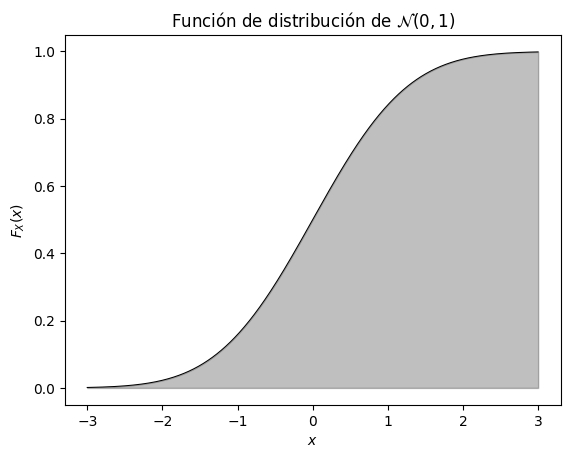

In [ ]:
x = np.linspace(-3, 3, 1000) #Dominio del gráfico
y = norm.cdf(x) #Función de distribución de la normal(0,1) en el dominio del gráfico
plt.plot(x, y, linewidth=0.75, color="black") #Represento el borde de dicha función
plt.fill_between(x, y, color="black", alpha=0.25) #Represento el relleno de dicha función con opacidad disminuida al 25%

plt.title(r"Función de distribución de $\mathcal{N}(0,1)$") #Título del gráfico (indicamos que va a contener caracteres extraños para evitar los warnings)
plt.xlabel("$x$") #Etiqueta al eje x
plt.ylabel("$F_X(x)$") #Etiqueta al eje y

plt.show()

Y ahora su función de densidad:

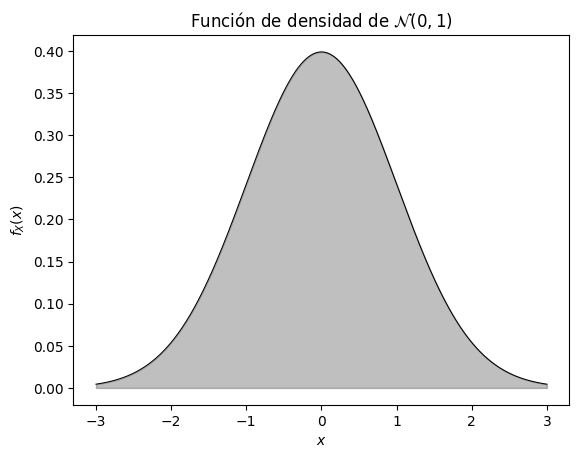

In [ ]:
x = np.linspace(-3, 3, 1000) #Dominio del gráfico
y = norm.pdf(x) #Función de densidad de la distribución normal(0,1) en el dominio del gráfico
plt.plot(x, y, linewidth=0.75, color="black") #Represento el borde de dicha función
plt.fill_between(x, y, color="black", alpha=0.25) #Represento el relleno de dicha función con opacidad disminuida al 25%

plt.title(r"Función de densidad de $\mathcal{N}(0,1)$") #Título del gráfico (indicamos que va a contener caracteres extraños para evitar los warnings)
plt.xlabel("$x$") #Etiqueta al eje x
plt.ylabel("$f_X(x)$") #Etiqueta al eje y

plt.show()

### **2.2 Representación de funciones de densidad y muestras de variables aleatorias normales con misma media pero distinta desviación típica**

Antes que nada, tomo muestras de $3$ distribuciones normales con media $0$ y desviaciones típicas $0.5$, $2$ y $5$ respectivamente. El tamaño de cada muestra será de $30$. Al no definir una semilla concreta, realizo estas simulaciones en una celda de código aislada para no recalcular las muestras cada vez que modifique algo de los gráficos.

In [ ]:
muestra_normal_0_05=np.random.normal(0,0.5,30) #Muestra de tamaño 30 de la distribución normal(0,0.5)
muestra_normal_0_2=np.random.normal(0,2,30) #Muestra de tamaño 30 de la distribución normal(0,2)
muestra_normal_0_5=np.random.normal(0,5,30) #Muestra de tamaño 30 de la distribución normal(0,5)

Represento las tres muestras de modo que se puedan visualizar conjuntamente la función de densidad de dichas variables aleatorias y las respectivas muestras:

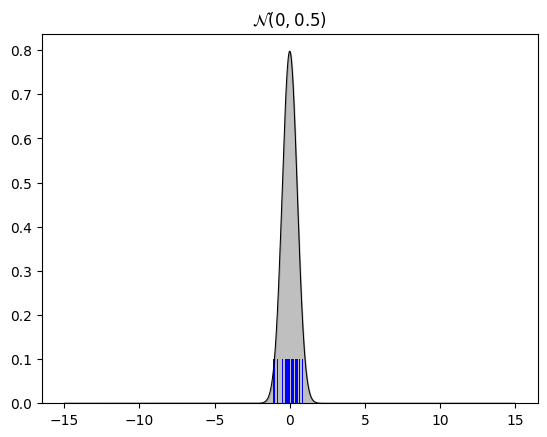

In [ ]:
x = np.linspace(-15, 15, 1000) #Dominio del gráfico
y = norm.pdf(x,scale=0.5) #Función de densidad de la distribución normal(0,0.5) en el dominio del gráfico
plt.plot(x, y, linewidth=0.75, color="black") #Represento el borde de dicha función
plt.fill_between(x, y, color="black", alpha=0.25) #Represento el relleno de dicha función con opacidad disminuida al 25%

plt.bar(muestra_normal_0_05,np.full(shape=muestra_normal_0_05.shape,fill_value=0.1), color="blue", width=0.05) #Represento dicha muestra como líneas finas

plt.title(r"$\mathcal{N}(0,0.5)$") #Título del gráfico

plt.show()

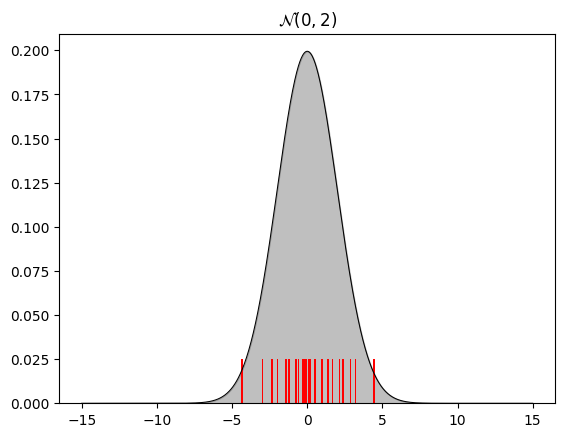

In [ ]:
x = np.linspace(-15, 15, 1000) #Dominio del gráfico
y = norm.pdf(x,scale=2) #Función de densidad de la distribución normal(0,0.5) en el dominio del gráfico
plt.plot(x, y, linewidth=0.75, color="black") #Represento el borde de dicha función
plt.fill_between(x, y, color="black", alpha=0.25) #Represento el relleno de dicha función con opacidad disminuida al 25%

plt.bar(muestra_normal_0_2,np.full(shape=muestra_normal_0_2.shape,fill_value=0.025), color='red', width=0.1) #Represento dicha muestra como líneas finas

plt.title(r"$\mathcal{N}(0,2)$") #Título del gráfico

plt.show()

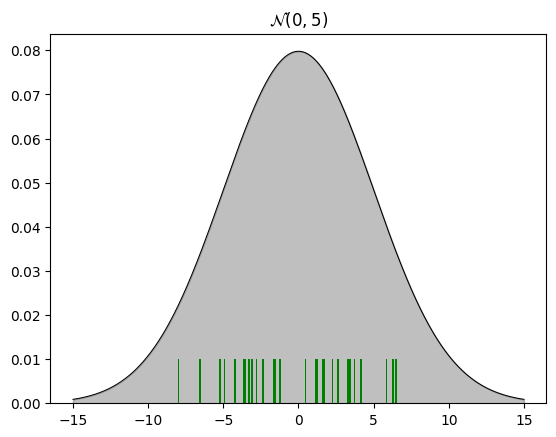

In [ ]:
x = np.linspace(-15, 15, 1000) #Dominio del gráfico
y = norm.pdf(x,scale=5) #Función de densidad de la distribución normal(0,0.5) en el dominio del gráfico
plt.plot(x, y, linewidth=0.75, color="black") #Represento el borde de dicha función
plt.fill_between(x, y, color="black", alpha=0.25) #Represento el relleno de dicha función con opacidad disminuida al 25%

plt.bar(muestra_normal_0_5,np.full(shape=muestra_normal_0_5.shape,fill_value=0.01), color='green', width=0.1) #Represento dicha muestra como líneas finas

plt.title(r"$\mathcal{N}(0,5)$") #Título del gráfico

plt.show()

### **2.3 Representación del Teorema de Chebychev en $100$ muestras de una normal tipificada**

Antes que nada, tomo una muestra de tamaño $100$ de una distribución normal tipificada ($X\rightarrow\mathcal{N}(0,1)$). Al no definir una semilla concreta, realizo esta simulación en una celda de código aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
muestra_normal=np.random.normal(size=100) #Muestra de tamaño 100 de la distribución normal(0,1)

Represento la muestra con sombreados proporcionales a la desviación típica entorno a la media.



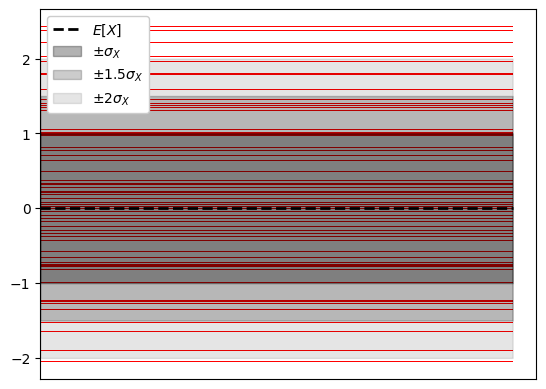

In [ ]:
plt.barh(muestra_normal, np.full(shape=muestra_normal.shape,fill_value=1), color="red", height=0.01) #Representamos dicha muestra como líneas finas horizontales

x = np.linspace(0, 1, 1000) #Dominio del gráfico
plt.plot([0,0], label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.
plt.fill_between(x, y1=1, y2=-1, color="black", label=r"$\pm\sigma_X$",alpha=0.3) #Región entre y1=(media teórica + desviación típica) e y2=(media teórica - desviación típica). Le pongo etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establezco su color y disminuyo su opacidad al 30%.
plt.fill_between(x, y1=1.5, y2=-1.5, color="black", label=r"$\pm1.5\sigma_X$",alpha=0.2) #Región entre y1=(media teórica + 2*desviación típica) e y2=(media teórica - 2*desviación típica). Le pongo etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establezco su color y disminuyo su opacidad al 20%.
plt.fill_between(x, y1=2, y2=-2, color="black", label=r"$\pm2\sigma_X$",alpha=0.1) #Región entre y1=(media teórica + 3*desviación típica) e y2=(media teórica - 3*desviación típica). Le pongo etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establezco su color y disminuyo su opacidad al 10%.

plt.legend(loc="upper left", framealpha=1) #Leyenda sin transparencia

plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) #Quito la escala del eje x

plt.show()

In [ ]:
print(np.sum(abs(muestra_normal)<1))
print(np.sum(abs(muestra_normal)<1.5))
print(np.sum(abs(muestra_normal)<2))

61
82
93


---



## **3. Simulaciones para el apartado de «Vectores Aleatorios»**
### **3.1 Representación de la función de densidad de una distribución normal bivariante**

Represento la función de densidad de un vector aleatorio $X \rightarrow\mathcal{N}(\begin{pmatrix} 0 \\ 0 \end{pmatrix},\begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix})$ de forma tridimensional.

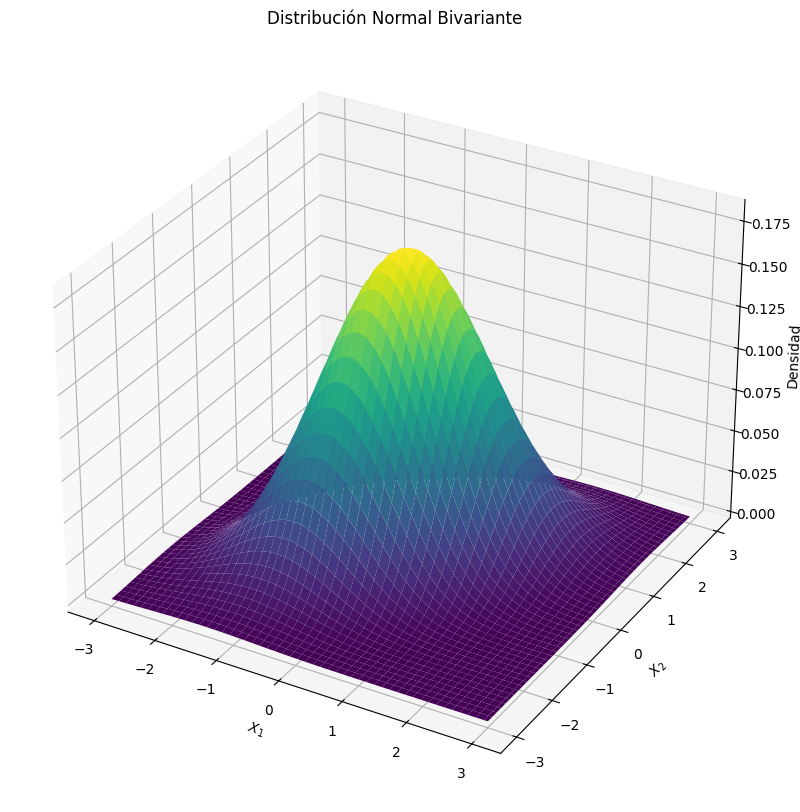

In [ ]:
Ex = np.array([0.0, 0.0])  #Media
Sx = np.array([[1.0, 0.5], [0.5, 1.0]])  #Matriz de covarianzas

x = np.linspace(-3, 3, 100) #Dominio del eje x del gráfico
y = np.linspace(-3, 3, 100) #Dominio del eje y del gráfico
X, Y = np.meshgrid(x, y) #Creo dos cuadrículas del dominio
pos = np.dstack((X, Y)) #Apilo las cuadrículas del dominio en una tercera dimensión

Distr_normal_biv = multivariate_normal(Ex, Sx) #Función de densidad de la distribución
Z = Distr_normal_biv.pdf(pos) #Evalúo la función de densidad en cada punto de la cuadrícula del dominio

fig = plt.figure(figsize=(10, 10)) #Creo la figura y defino su tamaño
ax = fig.add_subplot(projection="3d") #Añado un subgráfico 3D a la figura
surf = ax.plot_surface(X, Y, Z, cmap="viridis") #Dibujo la superficie en 3D y defino el mapa de calor de morado a amarillo

ax.set_title("Distribución Normal Bivariante") #Título del gráfico
ax.set_xlabel("$X_1$")  #Etiqueta al eje x
ax.set_ylabel("$X_2$")  #Etiqueta al eje y
ax.set_zlabel('Densidad')  #Etiqueta al eje z

plt.show()

Lo represento en mapa de calor.

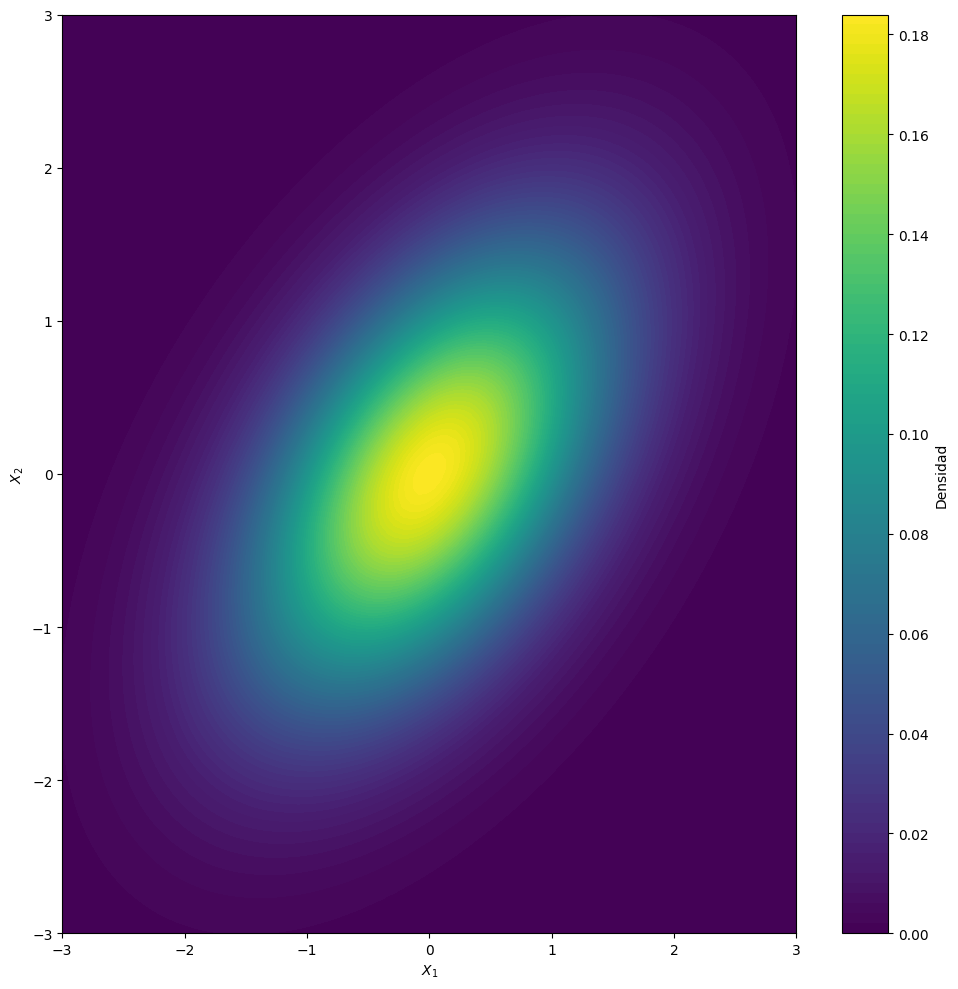

In [ ]:
fig=plt.figure(figsize=(10, 10)) #Creo la figura y defino su tamaño
ax=fig.add_subplot() #Añado un subgráfico a la figura
contour=ax.contourf(X, Y, Z, levels=100, cmap='viridis') #Dibujo el mapa de calor a 100 niveles y defino dicho mapa de morado a amarillo

ax.set_xlabel('$X_1$') #Etiqueta al eje x
ax.set_ylabel('$X_2$') #Etiqueta al eje y
fig.colorbar(contour, label='Densidad') #Etiqueta a la barra de color

plt.tight_layout() #Ajusto los márgenes y espacios para que no se solapen elementos
plt.show()

### **3.2 Representación de un diagrama de una variable bidimensional discreta**

En gráfico de barras tridimensional.

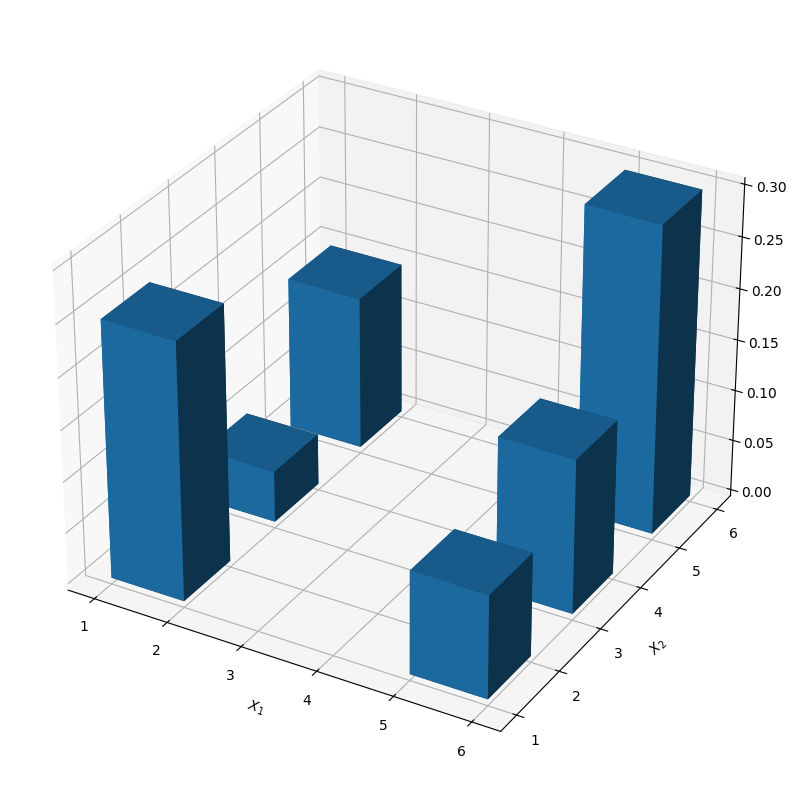

In [ ]:
fig=plt.figure(figsize=(10,10)) #Creo la figura y defino su tamaño
ax = fig.add_subplot(projection="3d") #Añado un subgráfico 3D a la figura

x=[1,5,1,5,1,5] #Coordenadas de x
y=[1,1,3,3,5,5] #Coordenadas de y
z=np.zeros(6) #Coordenadas de z

dx=np.ones(6) #Anchura de cada barra
dy=np.ones(6) #Profundidad de cada barra
dz=[0.25,0.1,0.05,0.15,0.15,0.30] #Altura de cada barra

ax.set_xlabel('$X_1$') #Etiqueta al eje x
ax.set_ylabel('$X_2$') #Etiqueta al eje y

ax.bar3d(x,y,z,dx,dy,dz) #Dibujo el gráfico de barras 3D con las posiciones y dimensiones definidas
plt.show()

Represento la distribución marginal de una de las componentes.

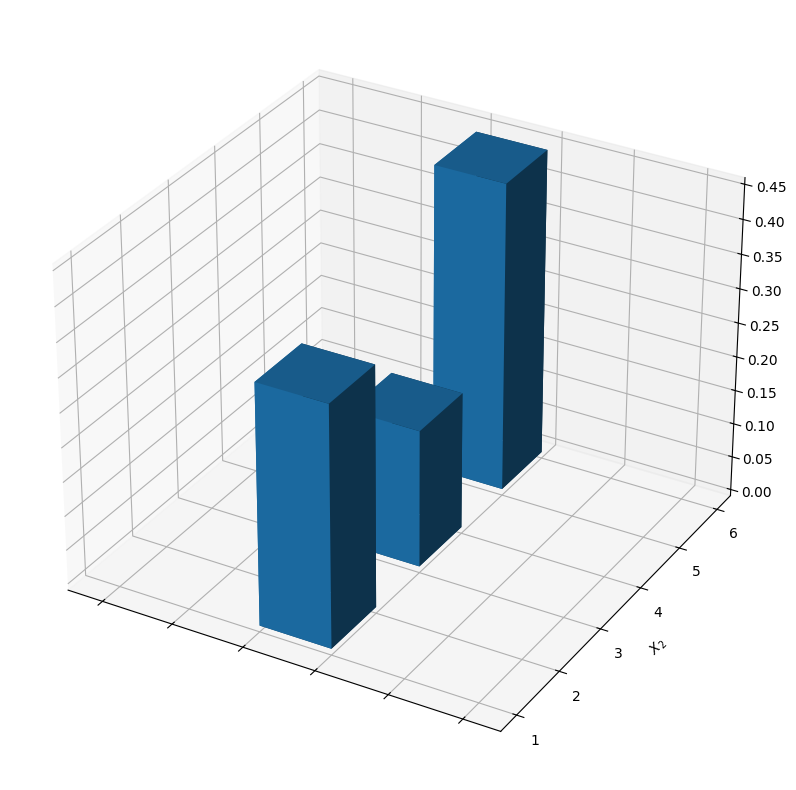

In [ ]:
fig=plt.figure(figsize=(10,10)) #Creo la figura y defino su tamaño
ax = fig.add_subplot(projection="3d") #Añado un subgráfico 3D a la figura

x=[0,0,0] #Coordenadas de x
y=[1,3,5] #Coordenadas de y
z=np.zeros(3) #Coordenadas de z

dx=np.ones(3) #Anchura de cada barra
dy=np.ones(3) #Profundidad de cada barra
dz=[0.35,0.2,0.45] #Altura de cada barra

ax.bar3d(x,y,z,dx,dy,dz) #Dibujo el gráfico de barras 3D con las posiciones y dimensiones definidas

ax.set_ylabel('$X_2$') #Etiqueta al eje y

plt.axis(xmin=-2.5, xmax=3.5) #Establezco los límites del eje x entre -2.5 y 3.5
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) #Quito la escala del eje x
plt.show()

---

## **4. Simulaciones para el apartado de «Procesos Estocásticos»**
### **4.1 Simulación y representación de una muestra de $X\rightarrow\mathcal{N}(0,1)$**

Antes que nada, tomo una muestra de tamaño 30 de una distribución normal tipificada ($X\rightarrow\mathcal{N}(0,1)$). Al no definir una semilla concreta, realizo esta simulación en una celda aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
muestra_normal=np.random.normal(size=30) #Muestra de tamaño 30 de una de la distribución normal(0,1)

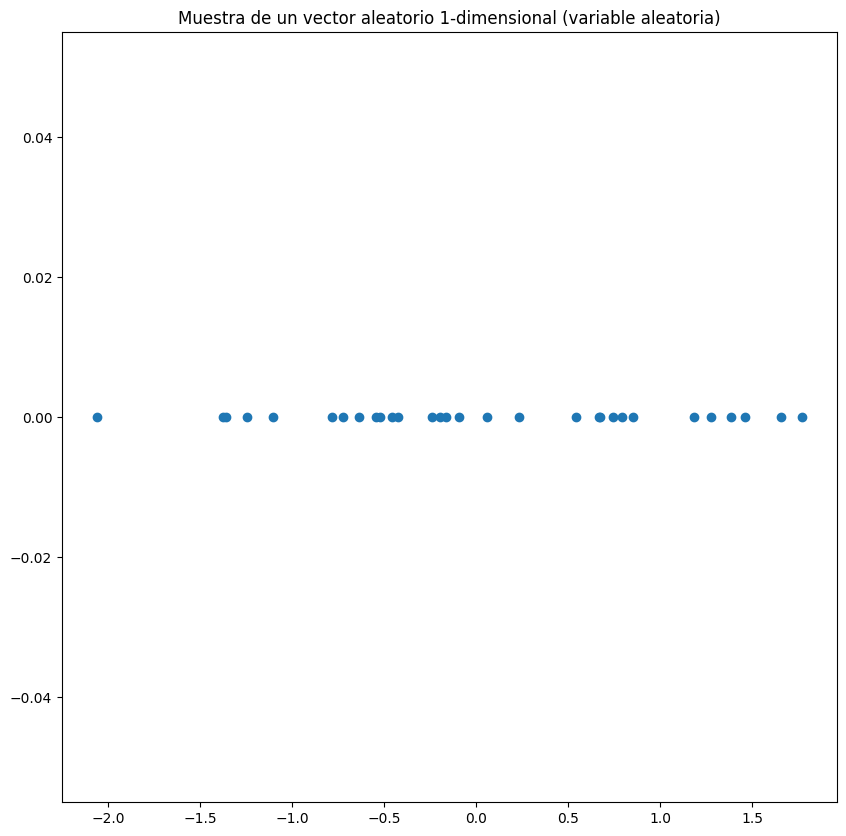

In [ ]:
plt.figure(figsize=(10,10)) #Defino el tamaño

plt.scatter(muestra_normal,np.zeros_like(muestra_normal))

plt.title("Muestra de un vector aleatorio 1-dimensional (variable aleatoria)")

plt.show()

### **4.2 Simulación y representación de una muestra de dicha distribución normal bivariante**

Antes que nada, tomo una muestra de tamaño $250$ la distribución normal bivariante $X \rightarrow\mathcal{N}(\begin{pmatrix} 0 \\ 0 \end{pmatrix},\begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix})$. Al no definir una semilla concreta, realizo esta simulación en una celda de código aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,250) #Muestra de tamaño 250 de una distribución normal bivariante.

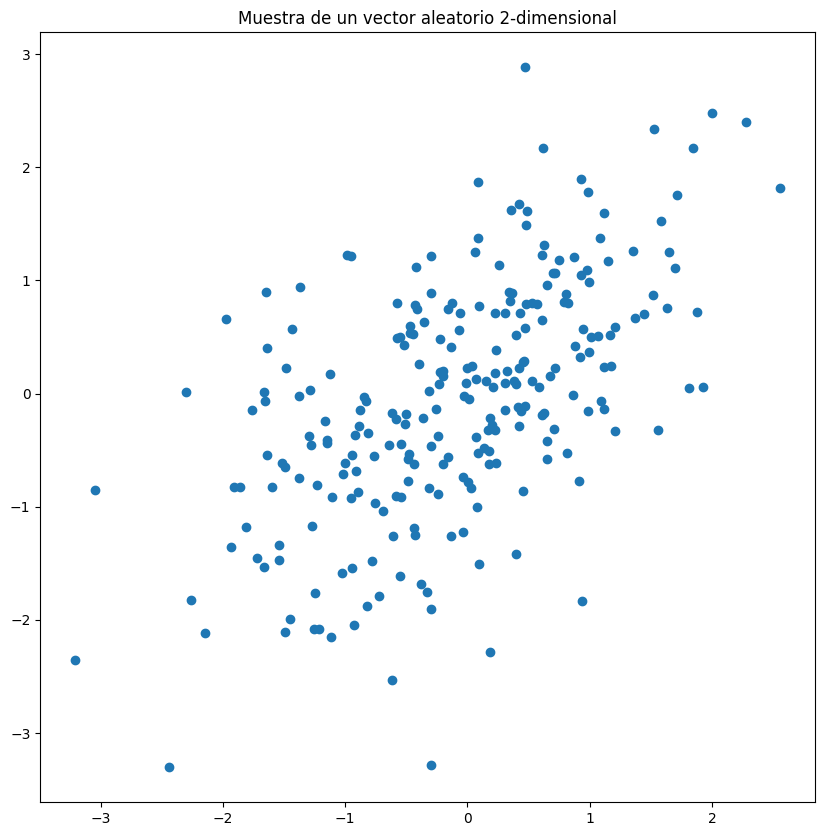

In [ ]:
plt.figure(figsize=(10,10)) #Defino el tamaño

x,y=np.split(muestra_normal_biv,2,axis=1) #Divido la muestra por componentes
plt.scatter(x,y) #Nube de puntos

plt.title("Muestra de un vector aleatorio 2-dimensional")

plt.show()

### **4.3 Simulación y representación de una muestra de dicha distribución normal multivariante tridimensional**

Antes que nada, tomo una muestra de tamaño $150$ la distribución normal multivariante tridimensional $X \rightarrow\mathcal{N}(\begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix},\begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3 \end{pmatrix})$. Al no definir una semilla concreta, realizo esta simulación en una celda de código aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
Ex = np.array([0.0, 0.0, 0.0])  #Media
Sx = np.array([[1, 0.0, 0.0], [0.0, 2, 0.0], [0.0, 0.0, 3]])  #Matriz de covarianzas
muestra_normal_tri=np.random.multivariate_normal(Ex,Sx,150) #Muestra de tamaño 150 de una distribución multivariante tridimensional

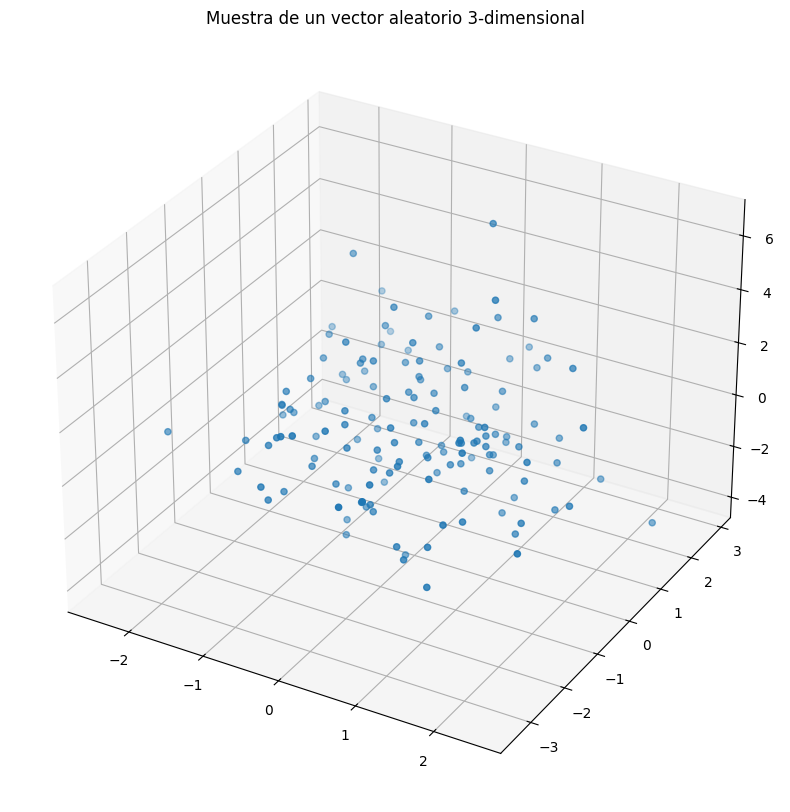

In [ ]:
x,y,z=np.split(muestra_normal_tri,3,axis=1) #Divido la muestra por componentes

fig=plt.figure(figsize=(10,10)) #Creo la figura y defino su tamaño
ax = fig.add_subplot(projection="3d") #Añado un subgráfico 3D a la figura

ax.scatter(x,y,z) #Nube de puntos

plt.title("Muestra de un vector aleatorio 3-dimensional")

plt.show()

### **4.4 Representaciones alternativas a las normales multivariantes bidimensional y tridimensional**

Se muestran unas representaciones alternativas a las anteriores que son escalables a vectores aleatorios con dimensionalidad mayor o igual que $4$.

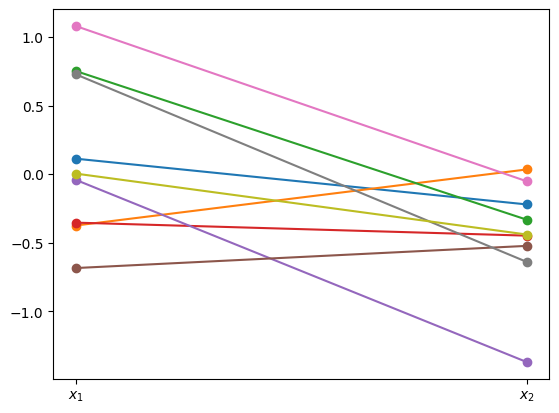

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.transpose(muestra_normal_biv[1:10]),"o-") #Represento una submuestra de tamaño 10 con puntos conectados

plt.show()

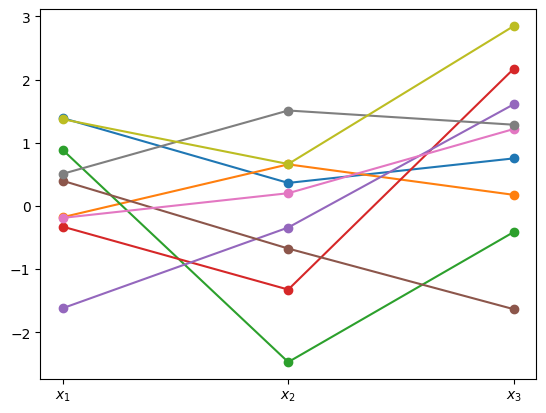

In [ ]:
plt.plot(["$x_1$","$x_2$","$x_3$"],np.transpose(muestra_normal_tri[1:10]),"o-") #Represento una submuestra de tamaño 10 con puntos conectados

plt.show()

Este tipo de visualizaciones sirven también para representar procesos estocásticos indexados en $\mathbb{N}$ o $\mathbb{R}$

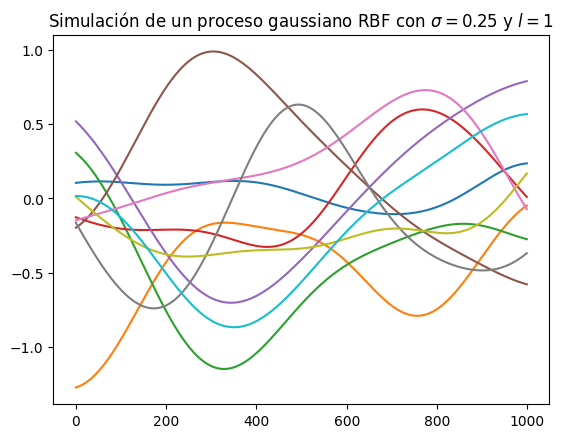

In [ ]:
t=np.linspace(0,5,1000) #Dominio

Sx=0.25 #Desviación típica
lengthscale=1 #Parámetro "lengthscale" de los procesos gaussianos RBF
n=10 #Número de simulaciones

Ex=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

matriz_dist=t.reshape(len(t),1)-t.reshape(1,len(t)) #Calculo la matriz de distancias que me servirá para calcular la matriz de covarianzas.
matriz_covs=Sx*np.exp((-1/2)*(matriz_dist/lengthscale)**2) #Calculo la matriz de covarianzas.

samples=np.random.multivariate_normal(Ex,matriz_covs,size=n) #Obtengo las muestras del proceso gaussiano.

plt.plot(np.transpose(samples)) #Represento las muestras.

plt.title(r"Simulación de un proceso gaussiano RBF con $\sigma=0.25$ y $l=1$")

plt.show()

### **4.5 Intuición de la covarianza entre componentes por su representación alternativa**

Representación de vectores bidimensionales con alta covarianza entre sus componentes. Concretamente $X \rightarrow\mathcal{N}(\begin{pmatrix} 0 \\ 0 \end{pmatrix},\begin{pmatrix} 1 & 0.9 \\ 0.9 & 1 \end{pmatrix})$ y $X \rightarrow\mathcal{N}(\begin{pmatrix} 1 \\ -1 \end{pmatrix},\begin{pmatrix} 1 & 0.9 \\ 0.9 & 1 \end{pmatrix})$. Al no definir una semilla concreta, realizo esta simulación en una celda de código aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
Ex = np.array([0.0, 0.0])
Sx = np.array([[1.0, 0.9], [0.9, 1.0]])
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,15)

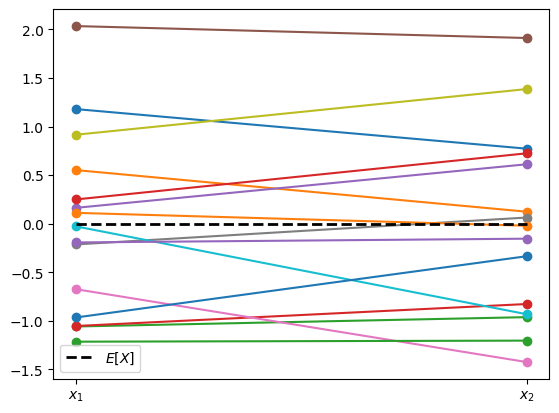

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.matrix_transpose(muestra_normal_biv), "o-")
plt.plot(Ex, label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.

plt.legend()

plt.show()

In [ ]:
Ex = np.array([1.0, -1.0])
Sx = np.array([[1.0, 0.9], [0.9, 1.0]])
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,15)

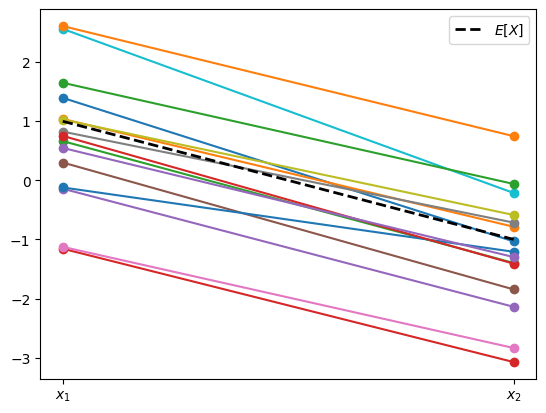

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.matrix_transpose(muestra_normal_biv), "o-")
plt.plot(Ex, label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.

plt.legend()

plt.show()

Representación de vectores bidimensionales con alta covarianza entre sus componentes. Concretamente $X \rightarrow\mathcal{N}(\begin{pmatrix} 0 \\ 0 \end{pmatrix},\begin{pmatrix} 1 & -0.9 \\ -0.9 & 1 \end{pmatrix})$ y $X \rightarrow\mathcal{N}(\begin{pmatrix} 1 \\ -1 \end{pmatrix},\begin{pmatrix} 1 & -0.9 \\ -0.9 & 1 \end{pmatrix})$. Al no definir una semilla concreta, realizo esta simulación en una celda de código aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
Ex = np.array([0.0, 0.0])
Sx = np.array([[1.0, -0.9], [-0.9, 1.0]])
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,15)

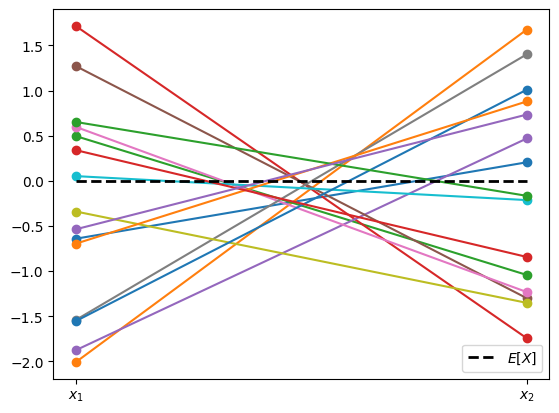

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.matrix_transpose(muestra_normal_biv), "o-")
plt.plot(Ex, label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.

plt.legend()

plt.show()

In [ ]:
Ex = np.array([1.0, -1.0])
Sx = np.array([[1.0, -0.9], [-0.9, 1.0]])
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,15)

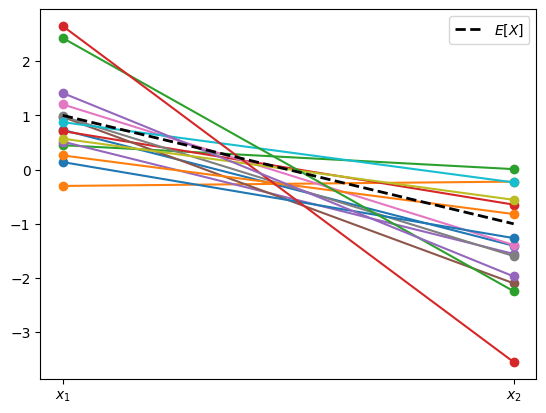

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.matrix_transpose(muestra_normal_biv), "o-")
plt.plot(Ex, label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.

plt.legend()

plt.show()

Representación de vectores bidimensionales con alta covarianza entre sus componentes. Concretamente $X \rightarrow\mathcal{N}(\begin{pmatrix} 0 \\ 0 \end{pmatrix},\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix})$ y $X \rightarrow\mathcal{N}(\begin{pmatrix} 1 \\ -1 \end{pmatrix},\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix})$. Al no definir una semilla concreta, realizo esta simulación en una celda de código aislada para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [ ]:
Ex = np.array([0.0, 0.0])
Sx = np.array([[1.0, 0.0], [0.0, 1.0]])
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,15)

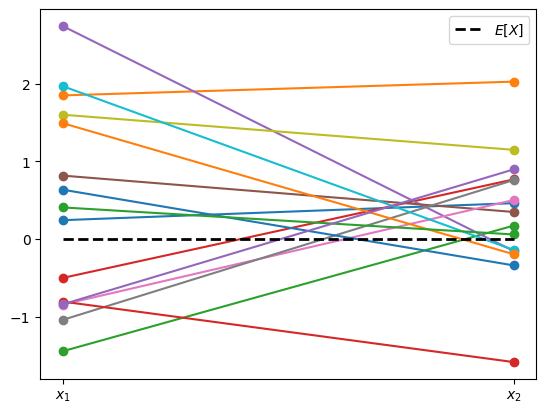

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.matrix_transpose(muestra_normal_biv), "o-")
plt.plot(Ex, label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.

plt.legend()

plt.show()

In [ ]:
Ex = np.array([1.0, -1.0])
Sx = np.array([[1.0, 0.0], [0.0, 1.0]])
muestra_normal_biv=np.random.multivariate_normal(Ex,Sx,15)

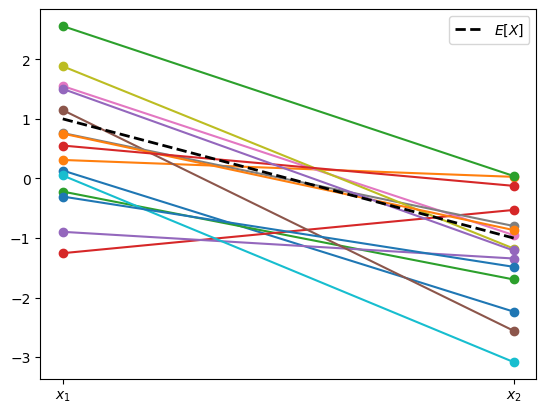

In [ ]:
plt.plot(["$x_1$","$x_2$"],np.matrix_transpose(muestra_normal_biv), "o-")
plt.plot(Ex, label="$E[X]$", linestyle="--", linewidth=2, color="black") #Media. Le pongo etiqueta para que se muestre en la leyenda, establezco su color, su estilo de línea discontinuo y aumento su grosor de linea.

plt.legend()

plt.show()

---

## **5. Simulaciones y representaciones para el apartado «Ejemplos y usos comunes»**
### **5.1 Simulación y representación del «Paseo Aleatorio Simple»**
Antes que nada, tomo $5$ trayectorias de una distribución finito-dimensional de $500$ pasos de un paseo aleatorio simple de probabilidad $p=0.5$ y otras $5$ trayectorias de una distribución finito-dimensional de $500$ pasos de un paseo aleatorio simple de probabilidad $p=0.6$. Al no definir una semilla concreta, realizo estas simulaciones en una celda de código aislada para no recalcular las muestras cada vez que modifique algo de los gráficos.

In [ ]:
muestra_pas=np.cumsum(2*(np.random.rand(5,500)<0.5)-1, axis=1)

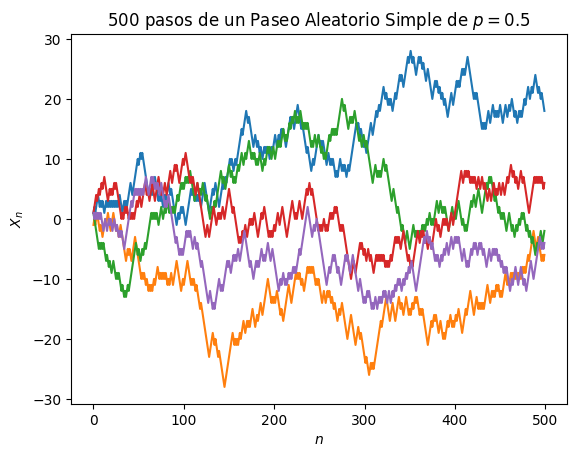

In [ ]:
plt.plot(np.transpose(muestra_pas))

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.title("$500$ pasos de un Paseo Aleatorio Simple de $p=0.5$")

plt.show()

In [ ]:
muestra_pas=np.cumsum(2*(np.random.rand(5,500)<0.6)-1, axis=1)

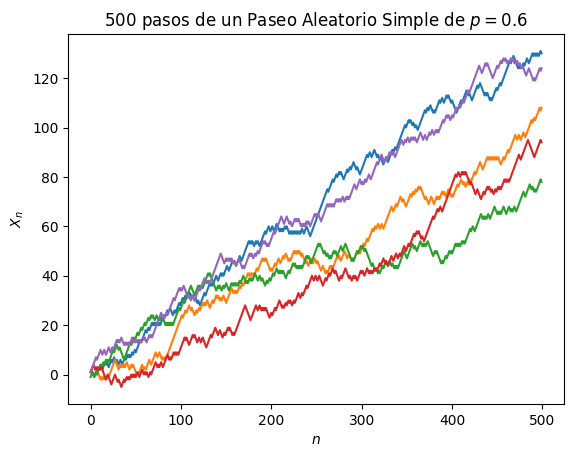

In [ ]:
plt.plot(np.transpose(muestra_pas))

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.title("$500$ pasos de un Paseo Aleatorio Simple de $p=0.6$")

plt.show()

### **5.2 Simulación y representación del PAS con el teorema de Chebychev**

In [ ]:
muestra_pas=np.cumsum(2*(np.random.rand(15,500)<0.5)-1, axis=1)

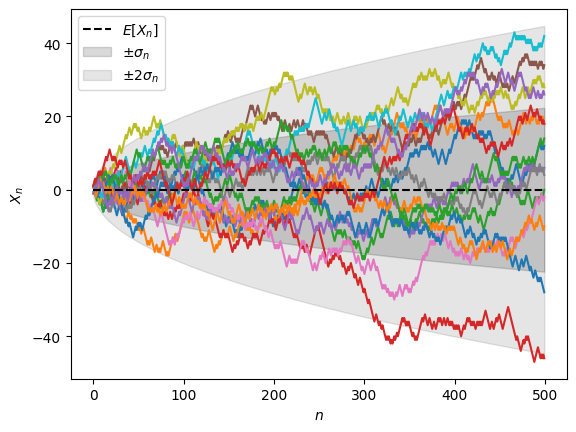

In [ ]:
Ex=(2*0.5-1)*np.arange(1,500+1)
Sx=(4*0.5*(1-0.5)*np.arange(1,500+1))**(1/2)

plt.plot(np.transpose(muestra_pas))
plt.plot(Ex, label="$E[X_n]$", linestyle="--", color="black") #Media teórica. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y su estilo de línea discontinuo.
plt.fill_between(x=list(range(0,500)), y1=Ex+Sx, y2=Ex-Sx, label=r"$\pm\sigma_n$", color='black', alpha=0.15) #Región entre y1=(media teórica + desviación típica) e y2=(media teórica - desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 15%.
plt.fill_between(x=list(range(0,500)), y1=Ex+2*Sx, y2=Ex-2*Sx, label=r"$\pm2\sigma_n$", color='black', alpha=0.1) #Región entre y1=(media teórica + 2*desviación típica) e y2=(media teórica - 2*desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 10%.

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.legend(loc="upper left") #Leyenda.

plt.show()

### **5.3 Simulación y representación de Procesos Gaussianos RBF**

Simulo y represento $3$ Procesos Gaussianos RBF con distinta varianza y lengthscale.

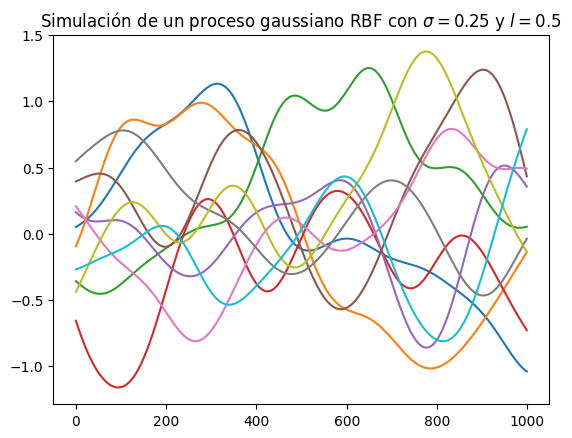

In [ ]:
t=np.linspace(0,5,1000) #Dominio

Sx=0.25 #Desviación típica
lengthscale=0.5 #Parámetro "lengthscale" de los procesos gaussianos RBF
n=10 #Número de simulaciones

Ex=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

matriz_dist=t.reshape(len(t),1)-t.reshape(1,len(t)) #Calculo la matriz de distancias que me servirá para calcular la matriz de covarianzas.
matriz_covs=Sx*np.exp((-1/2)*(matriz_dist/lengthscale)**2) #Calculo la matriz de covarianzas.

samples=np.random.multivariate_normal(Ex,matriz_covs,size=n) #Obtengo las muestras del proceso gaussiano.

plt.plot(np.transpose(samples)) #Represento las muestras.

plt.title(r"Simulación de un proceso gaussiano RBF con $\sigma=0.25$ y $l=0.5$")

plt.show()

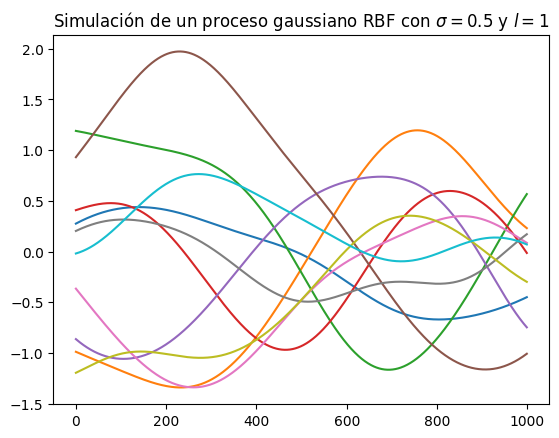

In [ ]:
t=np.linspace(0,5,1000) #Dominio

Sx=0.5 #Desviación típica
lengthscale=1 #Parámetro "lengthscale" de los procesos gaussianos RBF
n=10 #Número de simulaciones

Ex=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

matriz_dist=t.reshape(len(t),1)-t.reshape(1,len(t)) #Calculo la matriz de distancias que me servirá para calcular la matriz de covarianzas.
matriz_covs=Sx*np.exp((-1/2)*(matriz_dist/lengthscale)**2) #Calculo la matriz de covarianzas.

samples=np.random.multivariate_normal(Ex,matriz_covs,size=n) #Obtengo las muestras del proceso gaussiano.

plt.plot(np.transpose(samples)) #Represento las muestras.

plt.title(r"Simulación de un proceso gaussiano RBF con $\sigma=0.5$ y $l=1$")

plt.show()

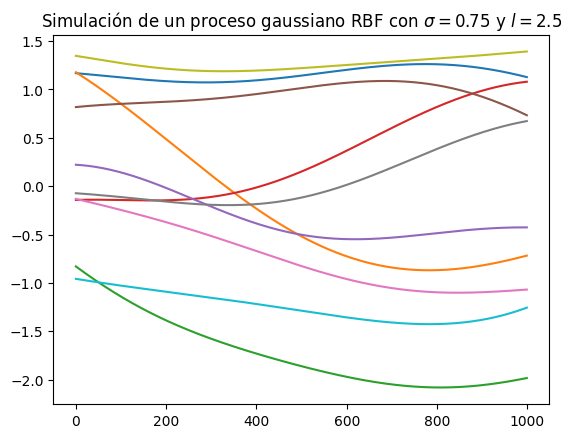

In [ ]:
t=np.linspace(0,5,1000) #Dominio

Sx=0.75 #Desviación típica
lengthscale=2.5 #Parámetro "lengthscale" de los procesos gaussianos RBF
n=10 #Número de simulaciones

Ex=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

matriz_dist=t.reshape(len(t),1)-t.reshape(1,len(t)) #Calculo la matriz de distancias que me servirá para calcular la matriz de covarianzas.
matriz_covs=Sx*np.exp((-1/2)*(matriz_dist/lengthscale)**2) #Calculo la matriz de covarianzas.

samples=np.random.multivariate_normal(Ex,matriz_covs,size=n) #Obtengo las muestras del proceso gaussiano.

plt.plot(np.transpose(samples)) #Represento las muestras.

plt.title(r"Simulación de un proceso gaussiano RBF con $\sigma=0.75$ y $l=2.5$")

plt.show()

## **6. Simulaciones y representaciones para el apartado «Modelo ARIMA»**
### **6.1 Simulación de un modelo $AR(3)$**
Antes que nada, tomo $1$ trayectoria de un modelo $AR(3)$ de $250$ pasos con $\phi_1=0.5$, $\phi_2=-0.25$ y $\phi_3=0.25$". Al no definir una semilla concreta, realizo estas simulaciones en una celda de código aislada para no recalcular las muestras cada vez que modifique algo de los gráficos.

In [ ]:
#Defino los parámetros
c=0.5
phi1=0.5
phi2=-0.25
phi3=0.25
Sx=1.0
n=250

#Simulo
X=np.zeros(n)
eps=np.random.normal(0, Sx, n)

for t in range(3, n):
    X[t]=c+phi1*X[t-1]+phi2*X[t-2]+phi3*X[t-3]+eps[t]

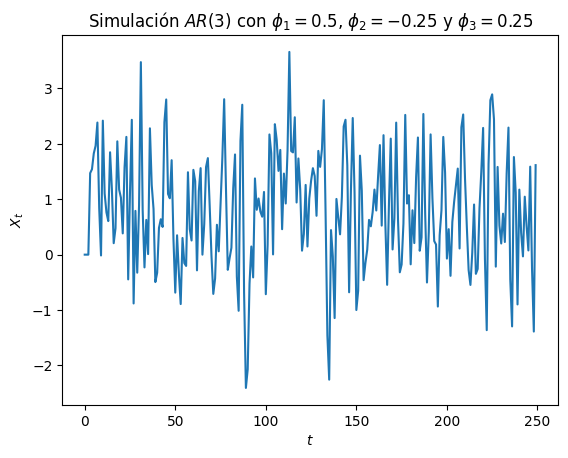

In [ ]:
plt.plot(X)

plt.xlabel("$t$") #Etiqueta al eje x
plt.ylabel("$X_t$") #Etiqueta al eje y

plt.title(r"Simulación $AR(3)$ con $\phi_1=0.5$, $\phi_2=-0.25$ y $\phi_3=0.25$") #Título

plt.show()

### **6.2 Simulación de un modelo $MA(2)$**
Antes que nada, tomo $1$ trayectoria de un modelo $MA(2)$ de $250$ pasos con $\theta_1=0.5$ y $\theta_2=-0.5$. Al no definir una semilla concreta, realizo estas simulaciones en una celda de código aislada para no recalcular las muestras cada vez que modifique algo de los gráficos.

In [ ]:
#Defino los parámetros
mu=0.5
theta1=0.5
theta2=-0.5
Sx=1.0
n=250

#Simulo
X=np.zeros(n)
eps=np.random.normal(0, Sx, n)

for t in range(2, n):
    X[t]=mu+theta1*eps[t-1]+theta2*eps[t-2]+eps[t]

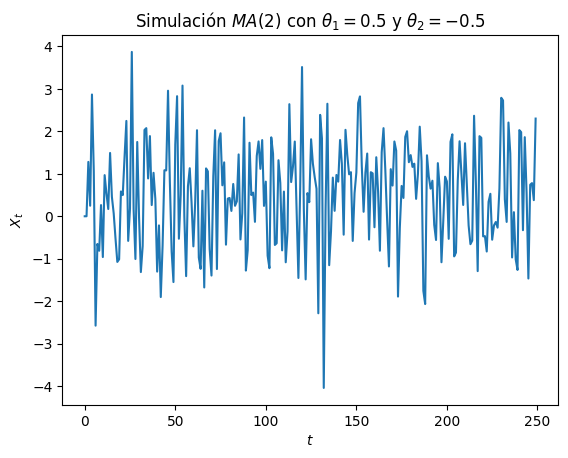

In [ ]:
plt.plot(X)

plt.xlabel("$t$") #Etiqueta al eje x
plt.ylabel("$X_t$") #Etiqueta al eje y

plt.title(r"Simulación $MA(2)$ con $\theta_1=0.5$ y $\theta_2=-0.5$") #Título

plt.show()

### **6.3 Simulación de un modelo $ARMA(3,2)$**
Antes que nada, tomo $1$ trayectoria de un modelo $ARMA(3,2)$ de $250$ pasos con $\phi_1=0.75$, $\phi_2=-0.25$, $\phi_3=0.25$, $\theta_1=0.5$ y $\theta_2=0.25$. Al no definir una semilla concreta, realizo estas simulaciones en una celda de código aislada para no recalcular las muestras cada vez que modifique algo de los gráficos.

In [ ]:
#Defino los parámetros
c=0.5
phi1=0.75
phi2=-0.25
phi3=0.25
theta1=0.5
theta2=-0.25
Sx=1.0
n=250

#Simulo
X=np.zeros(n)
eps=np.random.normal(0, Sx, n)

for t in range(3, n):
    X[t]=c+phi1*X[t-1]+phi2*X[t-2]+phi3*X[t-3]+eps[t]+theta1*eps[t-1] + theta2*eps[t-2]

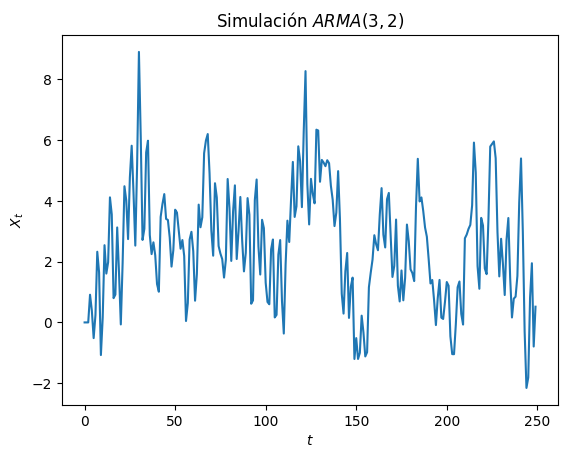

In [ ]:
plt.plot(X)

plt.xlabel("$t$") #Etiqueta al eje x
plt.ylabel("$X_t$") #Etiqueta al eje y

plt.title(r"Simulación $ARMA(3,2)$") #Título

plt.show()

### **6.4 Comparativa de predicciónes entre $ARMA(p,q)$ y $ARIMA(p,d,q)$**
Simulo un PIB trimestral con tendencia creciente y ciclos.

In [ ]:
n = 100  #25 años de datos trimestrales.
t = np.arange(n)

tendencia=10+0.005*t #Tendencia lineal (crecimiento del 0.5% por trimestre).

ciclo=0.5*np.sin(2*np.pi*t/20)  #Componente cíclico (recesiones y expansiones). Cada 5 años aprox.

shocks=np.random.normal(0, 0.1, n) #Fluctuaciones aleatorias.

PIB=tendencia+ciclo+shocks

Calculo el ajuste de un $ARMA(2,2)$ al PIB y lo grafico.

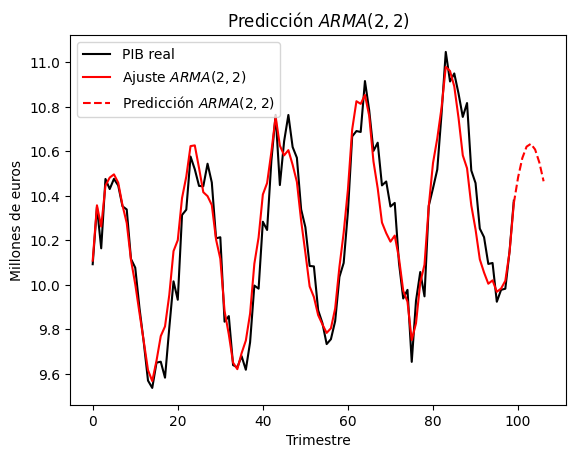

In [ ]:
modelo=ARIMA(PIB, order=(2,0,2)).fit() #Ajuste de un ARMA(2,2) al PIB

ajuste=modelo.predict(start=1, end=100)
prediccion=modelo.predict(start=100, end=107)

plt.plot(PIB, label="PIB real", color="black")
plt.plot(range(0, 100), ajuste, label="Ajuste $ARMA(2,2)$", color="red")
plt.plot(range(99, 107), prediccion, label="Predicción $ARMA(2,2)$", color="red", linestyle="--")

plt.xlabel("Trimestre")
plt.ylabel("Millones de euros")

plt.legend()

plt.title("Predicción $ARMA(2,2)$")

plt.show()

Ahora hago el ajuste de un $ARIMA(2,1,2)$ al PIB y lo grafico.

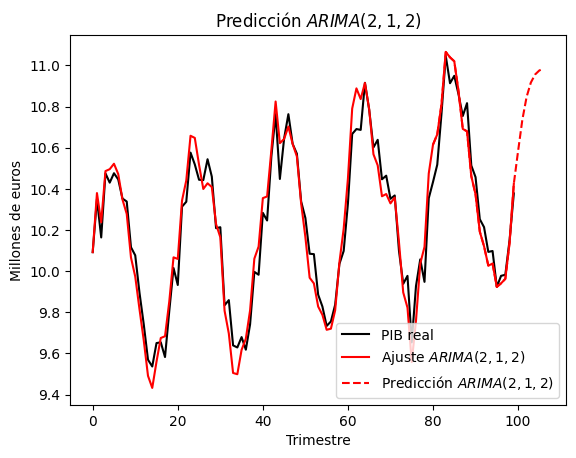

In [ ]:
modelo=ARIMA(PIB, order=(2,1,2)).fit() #Ajuste de un ARIMA(2,1,2) al PIB

ajuste=modelo.predict(start=1, end=100)
prediccion=modelo.predict(start=81, end=107)

plt.plot(PIB, label="PIB real", color="black")
plt.plot(range(0, 100), ajuste, label="Ajuste $ARIMA(2,1,2)$", color="red")
plt.plot(range(80, 107), prediccion, label="Predicción $ARIMA(2,1,2)$", color="red", linestyle="--")

plt.xlabel("Trimestre")
plt.ylabel("Millones de euros")

plt.legend()

plt.title("Predicción $ARIMA(2,1,2)$")

plt.show()